<div style="background: linear-gradient(135deg, #1e1b4b, #312e81); color:white; padding:25px; border-radius:10px; 
            text-align:center; font-family:'Segoe UI', sans-serif;">

  <h1 style="margin-bottom:8px;"> WikiArt Image Classification</h1>
  <h3 style="margin-top:0; font-style:italic; font-weight:normal; color:#a5b4fc;">
    Transfer Learning with ResNet50
  </h3>

  <hr style="width:60%; border:1px solid #6366f1; margin:15px auto;">

  <p style="margin:5px 0; font-size:15px;">
    <b>Group Project</b> - Deep Learning (2025/2026)
  </p>
  <p style="margin:0; font-size:13px; color:#c7d2fe;">
    Master in Data Science and Advanced Analytics - Nova Information Management School
  </p>
</div>

<br>

<div style="background-color:#1e293b; color:#e0e7ff; padding:15px 20px; border-left:5px solid #6366f1; 
            border-radius:6px; font-family:'Segoe UI', sans-serif; font-size:14px;">

  <b>Notebook Description</b><br>
  Transfer learning approach using a ResNet50 backbone pretrained on ImageNet, 
  fine-tuned for artist classification on the WikiArt dataset. 
  The model is evaluated using macro F1 score to account for class imbalance across the 23 artist categories.

</div>

<br>

<div style="background-color:#1e293b; color:#e0e7ff; padding:15px 20px; border-left:5px solid #6366f1; 
            border-radius:6px; font-family:'Segoe UI', sans-serif; font-size:14px;">

  <b>Project Authors</b><br>
  Carolina Luz - 20250409 - <a href="mailto:20250409@novaims.unl.pt" style="color:#a5b4fc;">20250409@novaims.unl.pt</a><br>
  Joao Paulo de Avila - 20250436 - <a href="mailto:20250436@novaims.unl.pt" style="color:#a5b4fc;">20250436@novaims.unl.pt</a><br>
  Lucas Ferreira - 20250448 - <a href="mailto:20250448@novaims.unl.pt" style="color:#a5b4fc;">20250448@novaims.unl.pt</a><br>
  Pedro Fernandes - 20250418 - <a href="mailto:20250418@novaims.unl.pt" style="color:#a5b4fc;">20250418@novaims.unl.pt</a><br>
  Pedro Santos - 20250399 - <a href="mailto:20250399@novaims.unl.pt" style="color:#a5b4fc;">20250399@novaims.unl.pt</a>

</div>

<br>

<div style="background-color:#1e293b; color:#e0e7ff; padding:15px 20px; border-left:5px solid #6366f1; 
            border-radius:6px; font-family:'Segoe UI', sans-serif; font-size:14px;">

  <b>GitHub Repository</b><br>
  <a href="https://github.com/joaopavila120/Deep-learning-project" target="_blank" style="color:#a5b4fc; text-decoration:none;">
    https://github.com/joaopavila120/Deep-learning-project
  </a>

</div>

<br>

<div style="text-align:right; font-size:12px; color:#94a3b8;">
  Last updated: march 2026
</div>

**<h3>Table of Contents</h3>**
* [1. Environment Setup](#1-environment-setup)
* [2. Model Implementation](#2-model)
* [3. Model Evaluation](#3-eval)


<div id="1-environment-setup" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#a5b4fc;">
    1. Setup
  </h2>
</div>

## 1.1 Libraries imports

In [1]:
import zipfile
import os
import shutil
import random
from collections import Counter
import re

# import utils functions auto-reload
%load_ext autoreload
%autoreload 2
from utils import *

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from keras import layers
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import sklearn.utils.class_weight as cw

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

set_seeds(42)

I0000 00:00:1775056057.383969   30199 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
train_dir = "data/train"
val_dir   = "data/val"
test_dir  = "data/test"

SEED = 42

<div id="2-model" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#a5b4fc;">
    2. Model Implementation
  </h2>
</div>

## 2.1 Transfer Learning using ResNet50

In [3]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 16
NUM_CLASSES = 23

train_ds, val_ds, test_ds, class_names = load_datasets(
    train_dir, val_dir, test_dir,
    img_size=IMG_SIZE, batch_size=BATCH_SIZE,
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

Found 9326 files belonging to 23 classes.


I0000 00:00:1775056064.455129   30199 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2244 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Found 1992 files belonging to 23 classes.
Found 2022 files belonging to 23 classes.
Classes (23): ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


In [4]:
# --- Data Augmentation ---
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

# --- Build Model ---
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = False  # freeze backbone

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)  # ResNet50 normalization (RGB→BGR, subtract mean)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="resnet50_transfer")
model.summary()

Model: "resnet50_transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 128, 128,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 128, 128)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 128, 128)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 128, 128)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 128, 128,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 4, 4,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 23)        │      5,911 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,118,167 (92.00 MB)

 Trainable params: 530,455 (2.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [5]:
# --- Train (Phase 1 — frozen backbone) ---
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy", keras.metrics.F1Score(average="macro", name="f1_macro")],
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath="models_results/resnet50/resnet50_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, checkpoint_callback],
)

Epoch 1/20


I0000 00:00:1775056083.315393   30341 cuda_dnn.cc:461] Loaded cuDNN version 92000


583/583 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.2678 - f1_macro: 0.2113 - loss: 2.7817
Epoch 1: val_loss improved from None to 1.72867, saving model to models_results/resnet50/resnet50_best.keras

Epoch 1: finished saving model to models_results/resnet50/resnet50_best.keras
583/583 ━━━━━━━━━━━━━━━━━━━━ 64s 82ms/step - accuracy: 0.3466 - f1_macro: 0.2927 - loss: 2.3202 - val_accuracy: 0.4834 - val_f1_macro: 0.4252 - val_loss: 1.7287
Epoch 2/20
583/583 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.4518 - f1_macro: 0.4023 - loss: 1.8781
Epoch 2: val_loss improved from 1.72867 to 1.56082, saving model to models_results/resnet50/resnet50_best.keras

Epoch 2: finished saving model to models_results/resnet50/resnet50_best.keras
583/583 ━━━━━━━━━━━━━━━━━━━━ 51s 79ms/step - accuracy: 0.4615 - f1_macro: 0.4170 - loss: 1.8395 - val_accuracy: 0.5261 - val_f1_macro: 0.4845 - val_loss: 1.5608
Epoch 3/20
583/583 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.4998 - f1_macro: 0.4539 - loss:

In [6]:
# --- Phase 2: Fine-tuning ---

# Unfreeze the last ~30 layers of ResNet50
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with very low LR to avoid destroying pretrained weights
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy", keras.metrics.F1Score(average="macro", name="f1_macro")],
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7, verbose=1
)

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop, reduce_lr, checkpoint_callback],
)

Epoch 1/30


W0000 00:00:1775057191.246515   30336 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.34GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


  2/583 ━━━━━━━━━━━━━━━━━━━━ 1:03 110ms/step - accuracy: 0.5469 - f1_macro: 0.2947 - loss: 1.4352 

W0000 00:00:1775057191.501782   30336 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.29GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


522/583 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step - accuracy: 0.5380 - f1_macro: 0.5076 - loss: 1.5314

...

524/583 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step - accuracy: 0.5381 - f1_macro: 0.5077 - loss: 1.5311

W0000 00:00:1775057256.446279   30339 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.28GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


583/583 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.5404 - f1_macro: 0.5104 - loss: 1.5230
Epoch 1: val_loss did not improve from 1.37375
583/583 ━━━━━━━━━━━━━━━━━━━━ 92s 138ms/step - accuracy: 0.5630 - f1_macro: 0.5365 - loss: 1.4392 - val_accuracy: 0.5753 - val_f1_macro: 0.5558 - val_loss: 1.5272 - learning_rate: 1.0000e-05
Epoch 2/30
573/583 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.6167 - f1_macro: 0.5865 - loss: 1.2716
Epoch 2: val_loss did not improve from 1.37375
583/583 ━━━━━━━━━━━━━━━━━━━━ 70s 114ms/step - accuracy: 0.6188 - f1_macro: 0.5918 - loss: 1.2597 - val_accuracy: 0.5899 - val_f1_macro: 0.5715 - val_loss: 1.5035 - learning_rate: 1.0000e-05
Epoch 3/30
583/583 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.6380 - f1_macro: 0.6077 - loss: 1.1830
Epoch 3: val_loss did not improve from 1.37375
583/583 ━━━━━━━━━━━━━━━━━━━━ 87s 140ms/step - accuracy: 0.6359 - f1_macro: 0.6109 - loss: 1.1856 - val_accuracy: 0.5929 - val_f1_macro: 0.5710 - val_loss: 1.4652 - learn

I0000 00:00:1775058768.756688   40084 shuffle_dataset_op.cc:453] ShuffleDatasetV3:24: Filling up shuffle buffer (this may take a while): 469 of 1000
I0000 00:00:1775058775.892020   40084 shuffle_dataset_op.cc:483] Shuffle buffer filled.


583/583 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.7133 - f1_macro: 0.6867 - loss: 0.9336
Epoch 20: ReduceLROnPlateau reducing learning rate to 1.56249996052793e-07.

Epoch 20: val_loss did not improve from 1.37375
583/583 ━━━━━━━━━━━━━━━━━━━━ 88s 120ms/step - accuracy: 0.7197 - f1_macro: 0.6975 - loss: 0.9180 - val_accuracy: 0.6295 - val_f1_macro: 0.6163 - val_loss: 1.4281 - learning_rate: 3.1250e-07
Epoch 21/30
583/583 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7228 - f1_macro: 0.7045 - loss: 0.9100
Epoch 21: val_loss did not improve from 1.37375
583/583 ━━━━━━━━━━━━━━━━━━━━ 87s 141ms/step - accuracy: 0.7210 - f1_macro: 0.7024 - loss: 0.9085 - val_accuracy: 0.6250 - val_f1_macro: 0.6147 - val_loss: 1.4378 - learning_rate: 1.5625e-07


<div id="3-eval" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#a5b4fc;">
    3. Model Evaluation
  </h2>
</div>

### Learning Curves

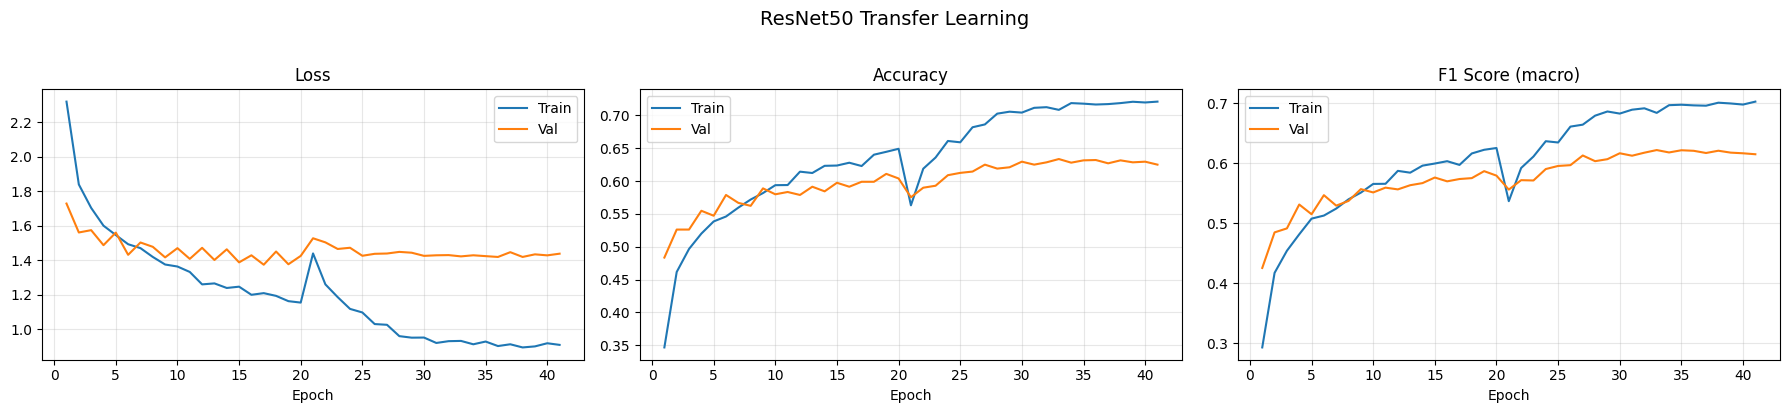

Best epoch (lowest val_loss): 17
  Val Loss: 1.3738
  Val Acc:  0.5989
  Val F1:   0.5734


In [7]:
plot_learning_curves([history_phase1, history_phase2], title="ResNet50 Transfer Learning")

### Test Evaluation


  ResNet50 Transfer Learning - Test Evaluation
  Test Loss:     1.5071
  Test Accuracy: 0.6128
  Test F1 Macro: 0.5902

Classification Report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.72      0.67      0.69        87
      Boris_Kustodiev       0.36      0.18      0.24        68
     Camille_Pissarro       0.57      0.47      0.51        94
        Childe_Hassam       0.48      0.42      0.45        59
         Claude_Monet       0.68      0.64      0.66       141
          Edgar_Degas       0.74      0.52      0.61        65
        Eugene_Boudin       0.86      0.71      0.78        59
         Gustave_Dore       0.82      0.90      0.86        80
           Ilya_Repin       0.42      0.38      0.40        58
      Ivan_Aivazovsky       0.82      0.89      0.85        62
        Ivan_Shishkin       0.76      0.52      0.62        56
  John_Singer_Sargent       0.77      0.67      0.72        83
         Marc_Chagall       0.63    

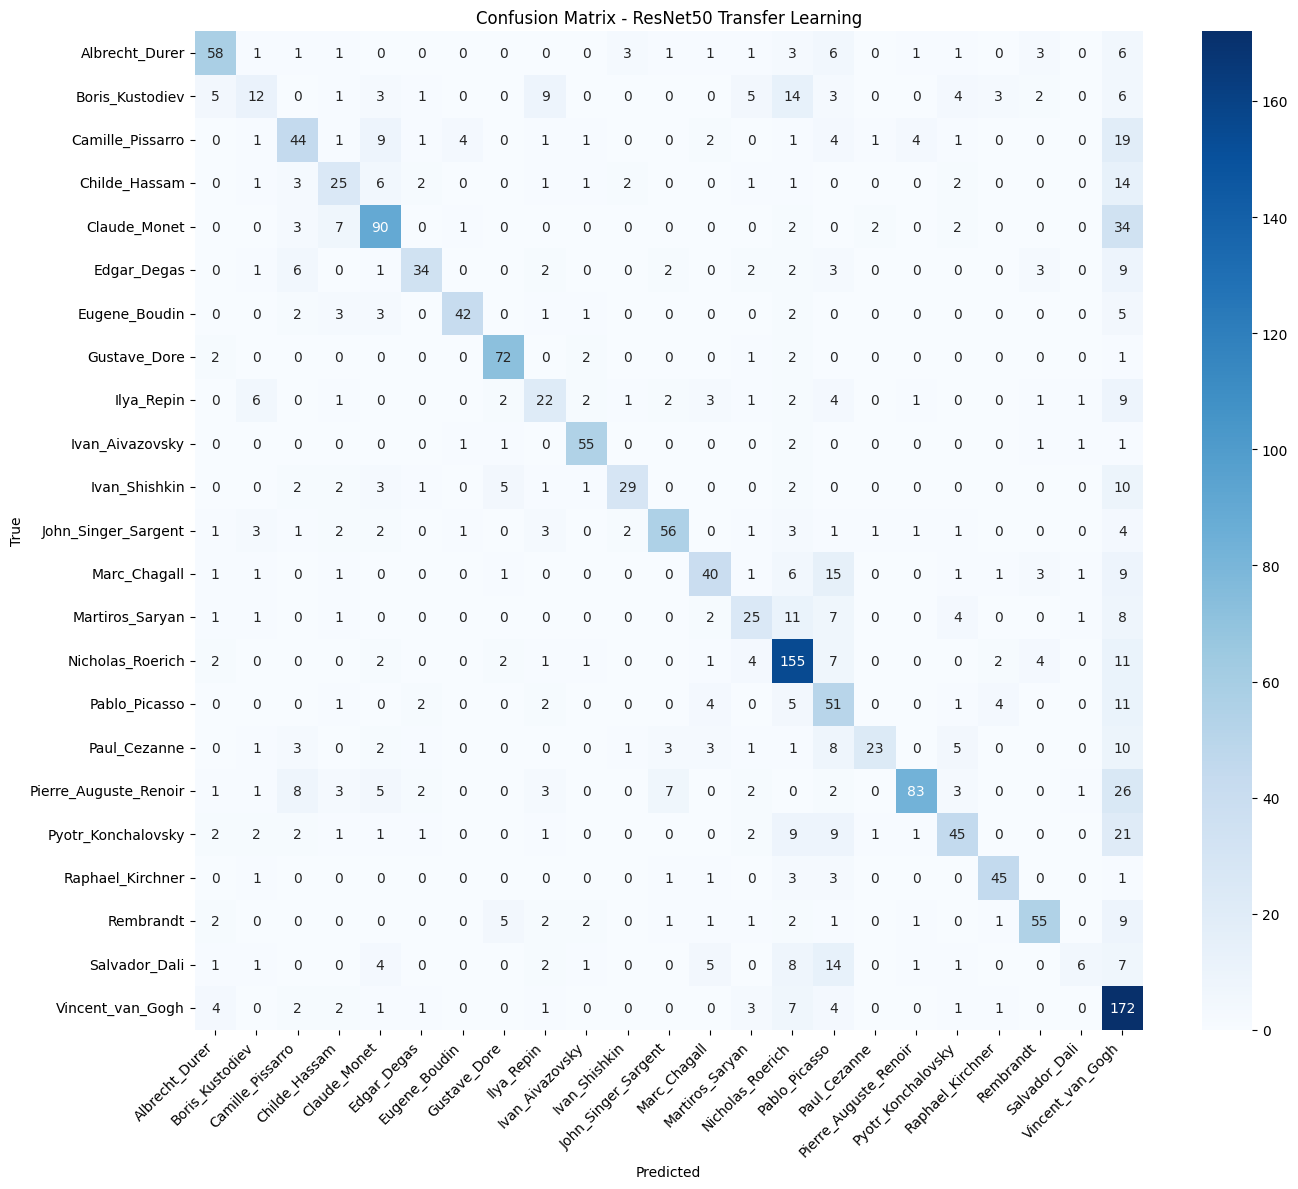

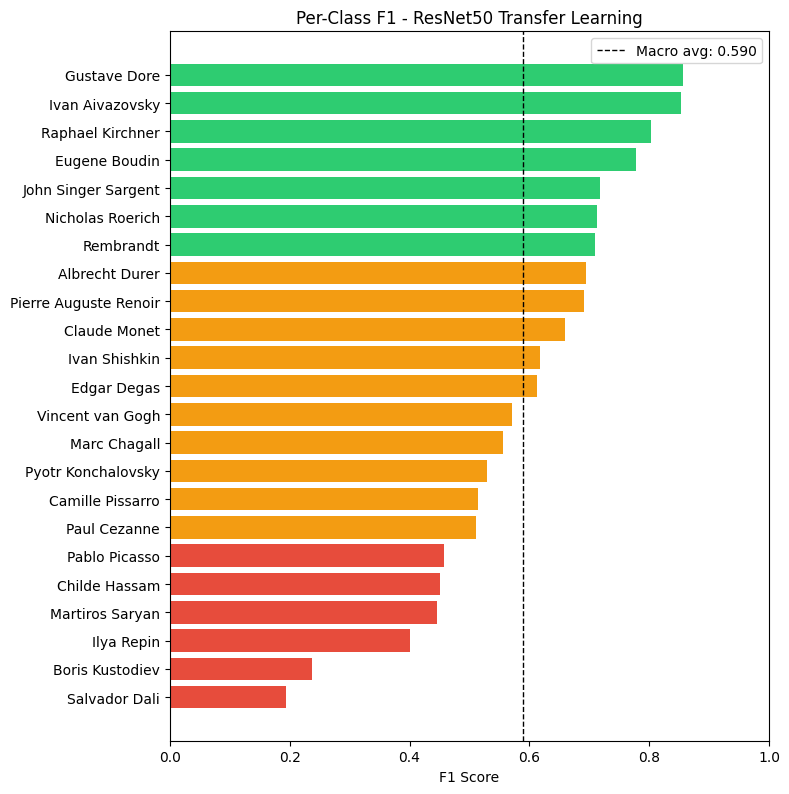

In [8]:
metrics_resnet = evaluate_model(model, test_ds, class_names, "ResNet50 Transfer Learning")

In [9]:
save_history([history_phase1, history_phase2], "models_results/resnet50/resnet50_history.json")

History saved to models_results/resnet50/resnet50_history.json
